# Recommendation System Evaluation

This notebook demonstrates comprehensive evaluation and visualization of Content-Based, Collaborative Filtering, and Hybrid recommendation models.

In [1]:
#%cd ..

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_processing.data_loader import MovieLensDataLoader
from src.data_processing.splitters import DataSplitter
from src.models.content_based import ContentBasedRecommender, ContentBasedConfig
from src.models.collaborative_filtering import CollaborativeFiltering
from src.models.hybrid import HybridRecommender
from src.models.cascading_hybrid import CascadingHybridRecommender
from src.models.popular_baseline_model import PopularityBaseline
from src.evaluation.evaluator import RecommendationEvaluator
from src.evaluation.visualisation import RecommendationVisualizer
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook', font_scale=1.1)

In [3]:
## 1. Load and Prepare Data

In [4]:
loader = MovieLensDataLoader("ml-latest-small")
data_dict = loader.load_data()
await loader.letterboxd_data_async(max_concurrent_requests=100)

movies_df = pd.DataFrame(loader.movie_data)
ratings_df = data_dict['ratings']
genre_features = loader.preprocess_movies()
movies_df = pd.concat([movies_df, genre_features], axis=1)
movies_df = movies_df.dropna().reset_index(drop=True)

print(f"Movies: {len(movies_df)}")
print(f"Ratings: {len(ratings_df)}")
print(f"Users: {ratings_df['userId'].nunique()}")





movies_df.head(10)

INFO:src.data_processing.data_loader:Loading MovieLens dataset...
INFO:src.data_processing.data_loader:Loading existing data from cache: data/processed/movie_metadata.parquet
INFO:src.data_processing.data_loader:Found 113 missing movies with valid TMDB IDs. Fetching...
INFO:src.data_processing.data_loader:DOWNLOAD SUMMARY: Requested: 113 | Saved: 0 | Failed: 113


Movies: 9589
Ratings: 100836
Users: 610


,movieId,title,year,cast,main_actor,director,rating,runtime,keywords,vote_count,...,genre_film-noir,genre_horror,genre_imax,genre_musical,genre_mystery,genre_romance,genre_sci-fi,genre_thriller,genre_war,genre_western
0,1.0,Toy Story,1995,"[Tom Hanks, Tim Allen, Don Rickles, Jim Varney...",Tom Hanks,John Lasseter,7.978,81.0,"[rescue, friendship, mission, jealousy, villai...",20023.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,Jumanji,1995,"[Robin Williams, Kirsten Dunst, Bradley Pierce...",Robin Williams,Joe Johnston,7.200,104.0,"[based on novel or book, giant insect, board g...",11353.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,Grumpier Old Men,1995,"[Walter Matthau, Jack Lemmon, Ann-Margret, Sop...",Walter Matthau,Howard Deutch,6.478,101.0,"[fishing, sequel, old man, best friend, weddin...",431.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,4.0,Waiting to Exhale,1995,"[Whitney Houston, Angela Bassett, Loretta Devi...",Whitney Houston,Forest Whitaker,6.243,127.0,"[based on novel or book, single mother, divorc...",206.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,5.0,Father of the Bride Part II,1995,"[Steve Martin, Diane Keaton, Martin Short, Kim...",Steve Martin,Charles Shyer,6.273,106.0,"[daughter, baby, parent child relationship, mi...",812.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,6.0,Heat,1995,"[Al Pacino, Robert De Niro, Val Kilmer, Jon Vo...",Al Pacino,Michael Mann,7.937,170.0,"[robbery, chase, obsession, detective, heist, ...",8403.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
6,7.0,Sabrina,1995,"[Harrison Ford, Julia Ormond, Greg Kinnear, Na...",Harrison Ford,Sydney Pollack,6.200,127.0,"[chauffeur, sibling relationship, paris, franc...",696.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
7,8.0,Tom and Huck,1995,"[Jonathan Taylor Thomas, Brad Renfro, Eric Sch...",Jonathan Taylor Thomas,Peter Hewitt,5.300,97.0,"[based on novel or book, mississippi river, ma...",214.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,9.0,Sudden Death,1995,"[Jean-Claude Van Damme, Powers Boothe, Raymond...",Jean-Claude Van Damme,Peter Hyams,6.034,111.0,"[explosive, hostage, ice hockey, terrorism, vi...",812.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,10.0,GoldenEye,1995,"[Pierce Brosnan, Sean Bean, Izabella Scorupco,...",Pierce Brosnan,Martin Campbell,6.903,130.0,"[computer virus, cuba, falsely accused, secret...",4353.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## 2. Split Data (Temporal Split)

In [5]:

splitter = DataSplitter(ratings_df)
splits = splitter.hybrid_stratified_split()
train_df = splits['train']
test_df = splits['test']

print(f"Train set: {len(train_df)} ratings")
print(f"Test set: {len(test_df)} ratings")
print(f"Train users: {train_df['userId'].nunique()}")
print(f"Test users: {test_df['userId'].nunique()}")

Train set: 70595 ratings
Test set: 14539 ratings
Train users: 610
Test users: 610


## 3. Train Models

In [6]:
#tags_df = pd.read_csv('/home/aquathirsty/Desktop/PFE/film-recommendations/data/raw/movielens/ml-latest-small/tags.csv')

config = ContentBasedConfig(
    main_actor_weight=0.15,
    director_weight=0.3,
    cast_weight=0.3,
    keywords_weight=0.6,
    numerical_weight=0.1,
    similarity_threshold=0.15,
    top_k_default=20
)

cb_model = ContentBasedRecommender(config=config)
i = 0
while i < 5:
    cb_model.fit(movies_df=movies_df,ratings_df=train_df)
    i+= 1

print("Content-Based model with tags trained successfully!")

2026-06-30 16:18:24.413 | INFO     | src.models.content_based:fit:618 - Starting model fitting
2026-06-30 16:18:24.420 | INFO     | src.models.content_based:fit:625 - Cleaning text columns
2026-06-30 16:18:24.482 | INFO     | src.models.content_based:fit:629 - Building cast and keyword strings
2026-06-30 16:18:24.483 | INFO     | src.models.content_based:fit:631 - Processing cast entries
Building keyword strings: 100%|██████████| 9589/9589 [00:00<00:00, 426271.91it/s]
2026-06-30 16:18:24.539 | INFO     | src.models.content_based:fit:638 - Preprocessing numerical and rating features
2026-06-30 16:18:24.540 | INFO     | src.models.content_based:_preprocess_numerical_features:124 - Preprocessing numerical features
2026-06-30 16:18:24.548 | DEBUG    | src.models.content_based:_fit_scaler:110 - Clipping runtime between 25.0 and 178.0
2026-06-30 16:18:24.569 | INFO     | src.models.content_based:_preprocess_actor_director_ratings:141 - Computing actor and director average ratings
2026-06-30 

Content-Based model with tags trained successfully!


In [7]:
cf_model = CollaborativeFiltering(k_components=110, random_state=42)
i = 0
while i < 5:
    cf_model.fit(df_ratings=train_df)
    i+= 1
print("Collaborative Filtering model trained successfully!")

2026-06-30 16:18:58.610 | INFO     | src.models.collaborative_filtering:__init__:110 - CollaborativeFiltering initialised. Explicit-feedback biased ALS model ready for training.
ALS epochs: 100%|██████████| 20/20 [00:03<00:00,  5.10it/s]
--- Step: Training complete ---
  Wall clock time : 4.08 s
  CPU time (user) : 45.15 s
  Memory RSS      : 449.7 MB
  Memory VMS      : 6339.3 MB
  CPU usage       : 0.0 %
2026-06-30 16:19:02.698 | INFO     | src.models.collaborative_filtering:fit:202 - Fitting complete | wall=4.09s cpu=45.17s mem=449.7MB
ALS epochs: 100%|██████████| 20/20 [00:02<00:00,  9.01it/s]
--- Step: Training complete ---
  Wall clock time : 2.29 s
  CPU time (user) : 28.56 s
  Memory RSS      : 452.4 MB
  Memory VMS      : 6341.8 MB
  RSS change      : +2.7 MB
  CPU usage       : 0.0 %
2026-06-30 16:19:04.985 | INFO     | src.models.collaborative_filtering:fit:202 - Fitting complete | wall=2.29s cpu=28.58s mem=452.4MB
ALS epochs: 100%|██████████| 20/20 [00:02<00:00,  9.29it/s]


Collaborative Filtering model trained successfully!


In [8]:
hybrid_model = HybridRecommender(
    cf_model=cf_model,
    cb_model=cb_model,
    alpha=0.8
)
hybrid_model.fitted(cf_model=cf_model, cb_model=cb_model, movies_df=movies_df, ratings_df=train_df)
print("Hybrid model trained successfully!")

Hybrid model trained successfully!


In [9]:
pop_model = PopularityBaseline()
pop_model.fit(train_df)
print("Popularity model trained successfully!")

Popularity model trained successfully!


In [10]:
cascading_hybrid_model = CascadingHybridRecommender(
    primary_model=cf_model,
    secondary_model=cb_model,
    primary_k=50
)
cascading_hybrid_model.fitted(primary_model=cf_model, secondary_model=cb_model)
print("Cascading hybrid model trained successfully!")

Cascading hybrid model trained successfully!


## 4. Evaluate Models

In [ ]:
models = {
    'Content-Based': cb_model,
    'Collaborative': cf_model,
    'Hybrid': hybrid_model,
    'Cascading Hybrid': cascading_hybrid_model,
    'Popularity': pop_model,
}

evaluator = RecommendationEvaluator(
    models=models,
    train_df=train_df,
    test_df=test_df,
    relevance_threshold=4.0,
    user_sample_size=None,
    random_state=42,
    n_negative_samples=99
)

results_df = evaluator.evaluate_all_models(
    k_values=[5, 10, 20],
    max_recommendations=20
    
)

print("Evaluation completed!")
print(f"Results shape: {results_df.shape}")

2026-06-30 16:19:11.966 | INFO     | src.evaluation.evaluator:evaluate_model:121 - Evaluating 'Content-Based'
Batch recommendations: 100%|██████████| 610/610 [00:00<00:00, 969.17it/s]
2026-06-30 16:19:12.639 | INFO     | src.models.content_based:get_top_k_recommendations_batch:466 - Batch recommendation complete
2026-06-30 16:19:12.725 | INFO     | src.evaluation.evaluator:evaluate_model:270 - 'Content-Based' done in 0.8s
2026-06-30 16:19:12.726 | INFO     | src.evaluation.evaluator:evaluate_model:121 - Evaluating 'Collaborative'
2026-06-30 16:19:13.093 | INFO     | src.evaluation.evaluator:evaluate_model:270 - 'Collaborative' done in 0.4s
2026-06-30 16:19:13.094 | INFO     | src.evaluation.evaluator:evaluate_model:121 - Evaluating 'Hybrid'
Hybrid:   0%|          | 0/1 [00:00<?, ?it/s]2026-06-30 16:19:13.097 | WARNING  | src.evaluation.evaluator:evaluate_model:178 - Batch error for Hybrid: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all(). Fall

Evaluation completed!
Results shape: (15, 10)


In [12]:
results_df

,model,k,precision,recall,ndcg,map,mrr,novelty,coverage,n_users
0,Content-Based,5,0.071186,0.037705,0.082706,0.047719,0.163701,9.315351,0.032273,162
1,Content-Based,10,0.062881,0.072805,0.087013,0.040178,0.179400,9.405245,0.049696,230
2,Content-Based,20,0.054746,0.122723,0.098993,0.038405,0.188908,9.488902,0.077877,312
3,Collaborative,5,0.039322,0.026937,0.045427,0.025364,0.084266,9.834441,0.059635,96
4,Collaborative,10,0.032203,0.037489,0.045806,0.021160,0.094830,9.940996,0.082905,143
5,Collaborative,20,0.029915,0.066945,0.054206,0.020332,0.103884,10.098190,0.111436,221
6,Hybrid,5,0.052881,0.031938,0.063013,0.036200,0.123503,9.552151,0.041277,125
7,Hybrid,10,0.041525,0.043834,0.060005,0.028406,0.132980,9.755433,0.069457,167
8,Hybrid,20,0.033559,0.071775,0.064202,0.025331,0.140544,10.017487,0.117633,232
9,Cascading Hybrid,5,0.064407,0.040567,0.071338,0.039726,0.129774,9.323052,0.024205,148


## 5. Visualizations

In [13]:
visualizer = RecommendationVisualizer(results_df)

### 5.1 Precision@K Trend

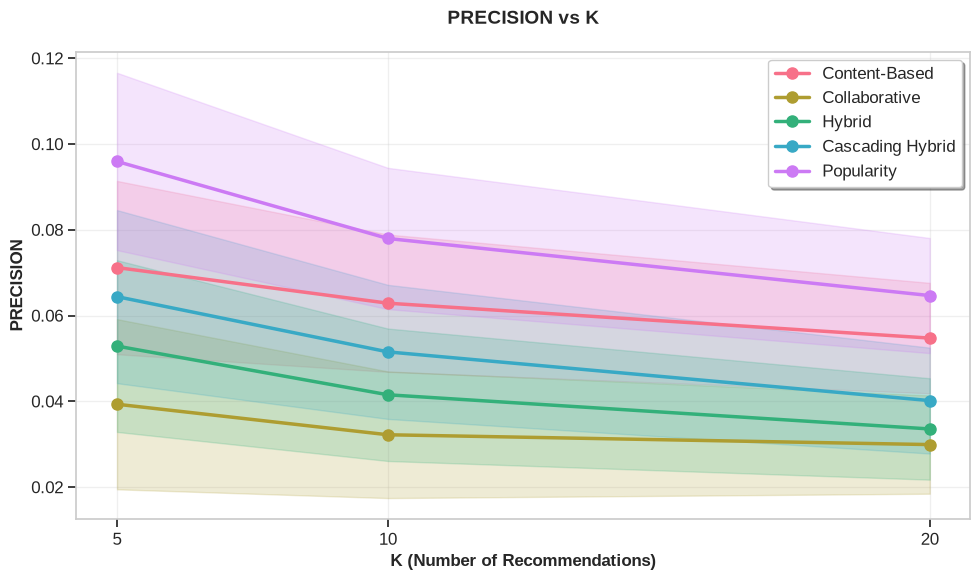

In [14]:
fig = visualizer.plot_metric_trend('precision', figsize=(10, 6))
plt.show()

### 5.2 Recall@K Trend

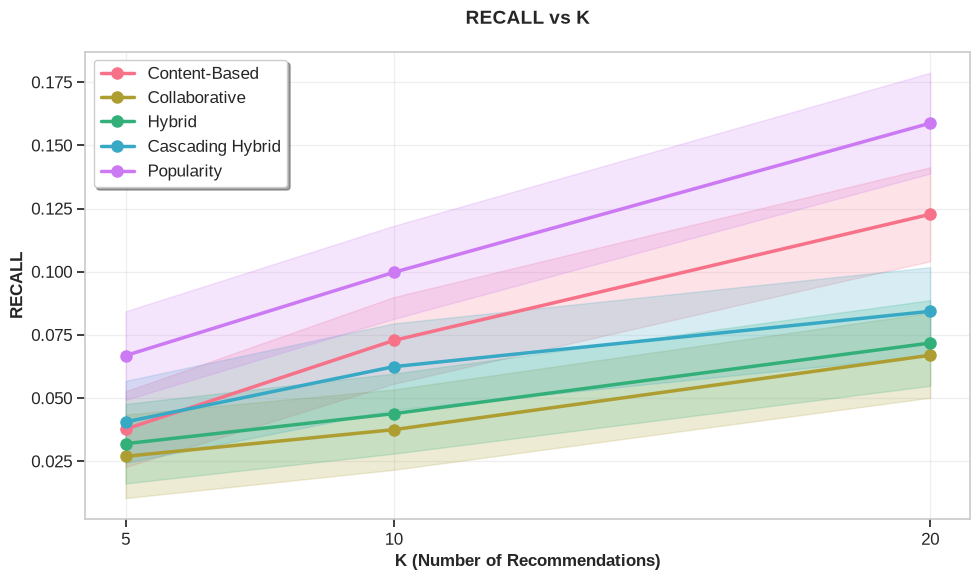

In [15]:
fig = visualizer.plot_metric_trend('recall', figsize=(10, 6))
plt.show()

### 5.3 NDCG@K Trend

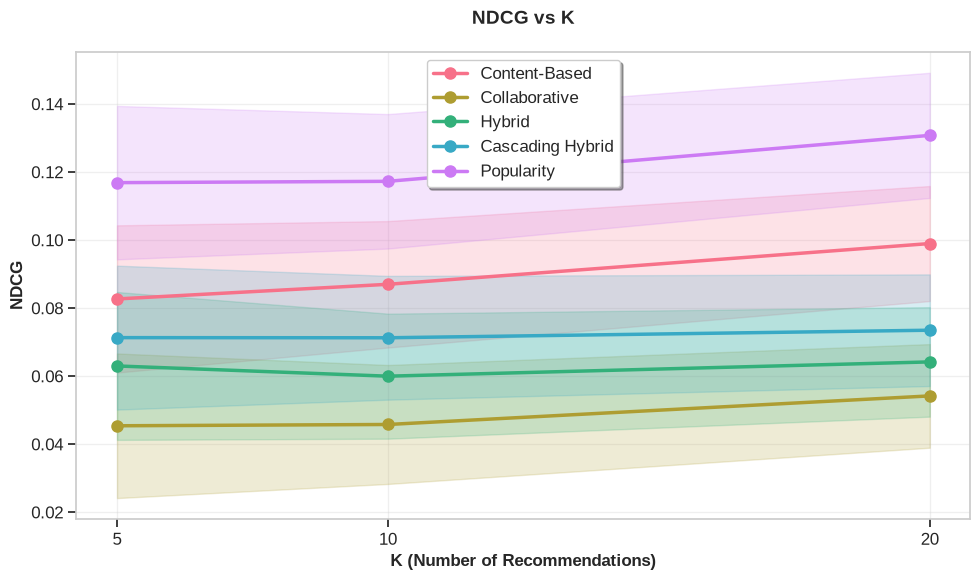

In [16]:
fig = visualizer.plot_metric_trend('ndcg', figsize=(10, 6))
plt.show()

### 5.4 Model Comparison at K=10

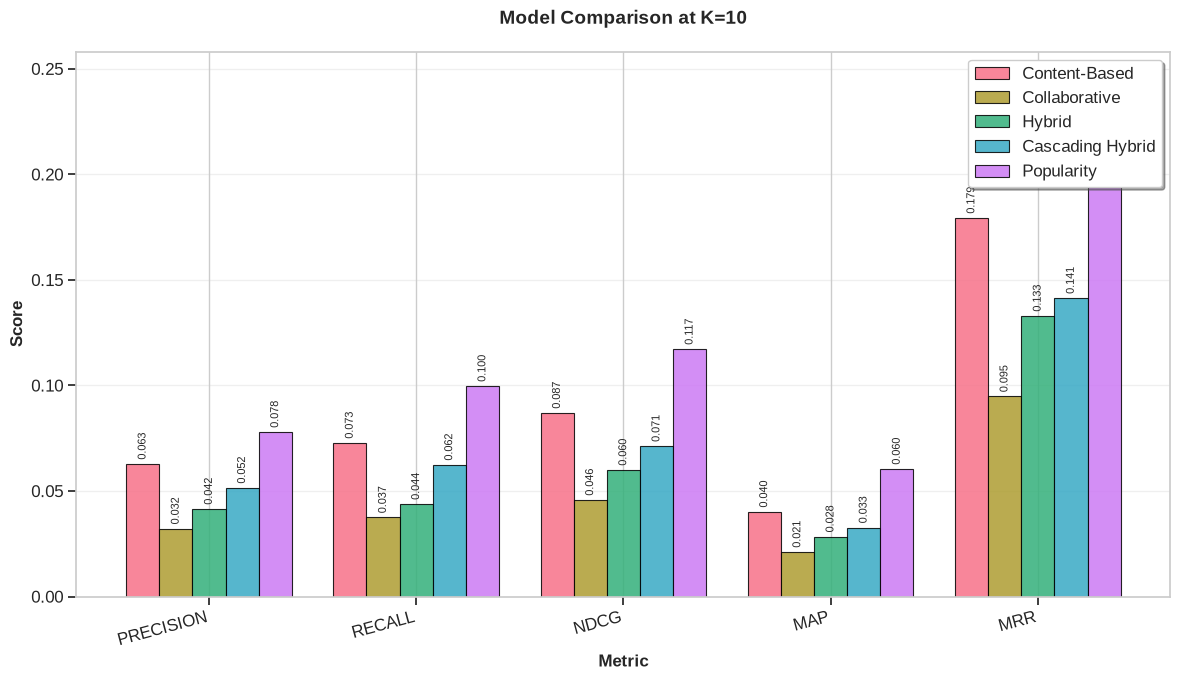

In [17]:
fig = visualizer.plot_model_comparison(k=10, figsize=(12, 7))
plt.show()

### 5.5 Performance Heatmap at K=10

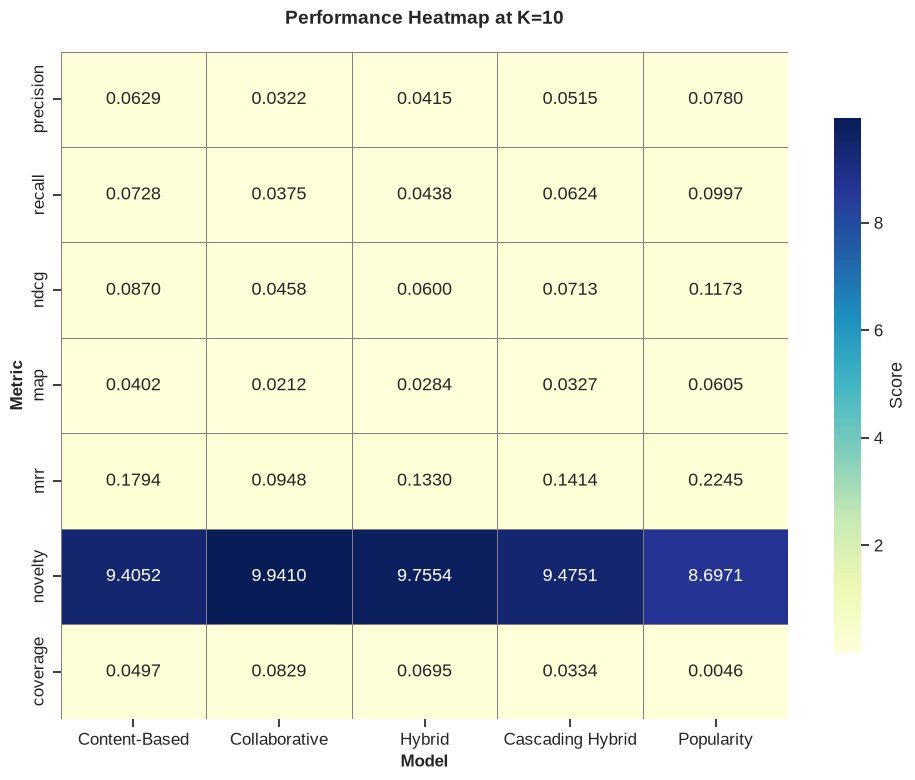

In [18]:
fig = visualizer.plot_all_metrics_heatmap(k=10, figsize=(10, 8))
plt.show()

### 5.6 Coverage vs Novelty Trade-off

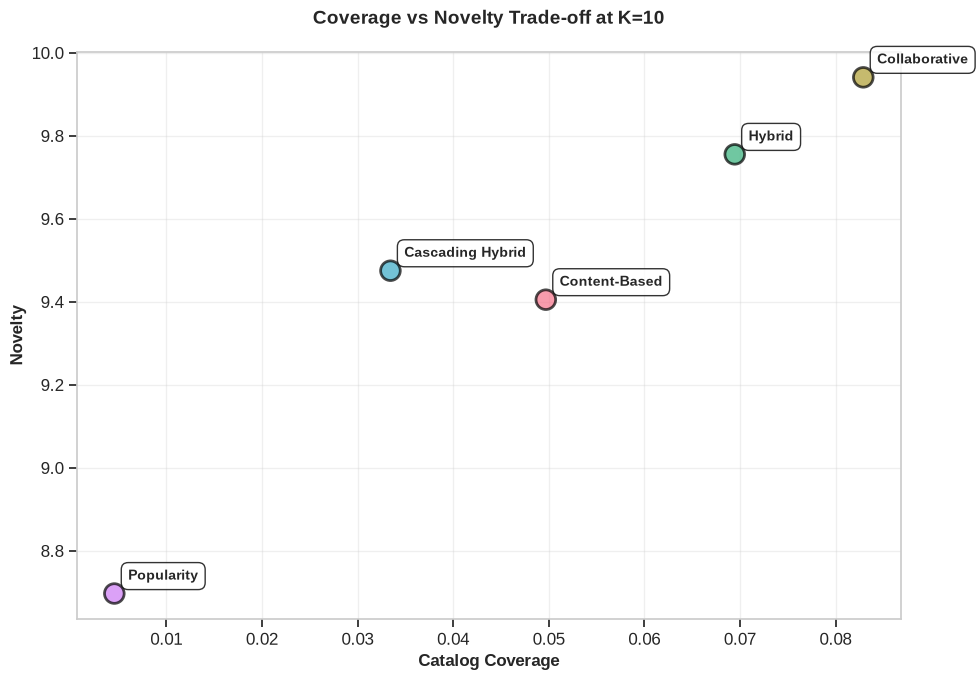

In [19]:
fig = visualizer.plot_coverage_novelty_tradeoff(k=10, figsize=(10, 7))
plt.show()

### 5.7 Radar Chart Comparison

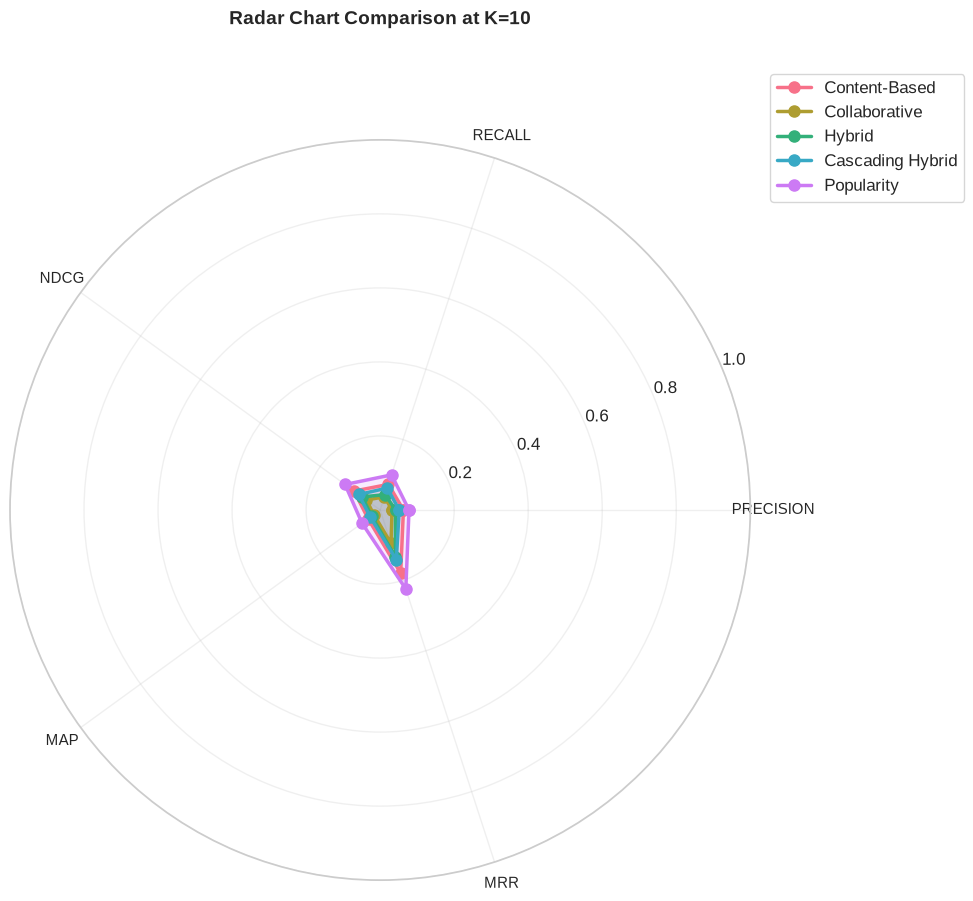

In [20]:
fig = visualizer.plot_radar_chart(k=10, figsize=(10, 10))
plt.show()

## 6. Save All Plots

In [21]:
visualizer.save_all_plots(output_dir="evaluation_plots")
print("All plots saved to evaluation_plots/")

INFO:src.evaluation.visualisation:All plots saved to evaluation_plots/


All plots saved to evaluation_plots/


## 7. Summary Statistics

In [22]:
print("=" * 80)
print("EVALUATION SUMMARY (K=10)")
print("=" * 80)

k10_results = results_df[results_df['k'] == 10]

for model in k10_results['model'].unique():
    model_data = k10_results[k10_results['model'] == model].iloc[0]
    print(f"\n{model.upper()}:")
    print(f"  Precision@10: {model_data['precision']:.4f}")
    print(f"  Recall@10:    {model_data['recall']:.4f}")
    print(f"  NDCG@10:      {model_data['ndcg']:.4f}")
    print(f"  MAP@10:       {model_data['map']:.4f}")
    print(f"  MRR:          {model_data['mrr']:.4f}")
    print(f"  Novelty:      {model_data['novelty']:.4f}")
    print(f"  Coverage:     {model_data['coverage']:.4f}")

print("\n" + "=" * 80)

EVALUATION SUMMARY (K=10)

CONTENT-BASED:
  Precision@10: 0.0629
  Recall@10:    0.0728
  NDCG@10:      0.0870
  MAP@10:       0.0402
  MRR:          0.1794
  Novelty:      9.4052
  Coverage:     0.0497

COLLABORATIVE:
  Precision@10: 0.0322
  Recall@10:    0.0375
  NDCG@10:      0.0458
  MAP@10:       0.0212
  MRR:          0.0948
  Novelty:      9.9410
  Coverage:     0.0829

HYBRID:
  Precision@10: 0.0415
  Recall@10:    0.0438
  NDCG@10:      0.0600
  MAP@10:       0.0284
  MRR:          0.1330
  Novelty:      9.7554
  Coverage:     0.0695

CASCADING HYBRID:
  Precision@10: 0.0515
  Recall@10:    0.0624
  NDCG@10:      0.0713
  MAP@10:       0.0327
  MRR:          0.1414
  Novelty:      9.4751
  Coverage:     0.0334

POPULARITY:
  Precision@10: 0.0780
  Recall@10:    0.0997
  NDCG@10:      0.1173
  MAP@10:       0.0605
  MRR:          0.2245
  Novelty:      8.6971
  Coverage:     0.0046

